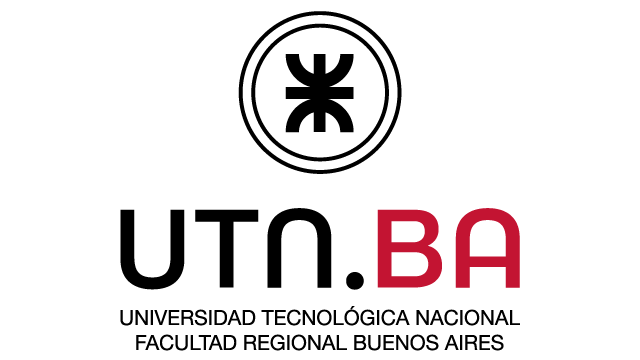

## 1er Parcial: Diseño de mezclador de audio

## Año: 2026

## Curso: R4053

## Grupo: 5

Profesores:
    
    1) Ing. Eduardo Marchionni
    2) Ing. Gustavo Randazzo
    3) Ing. Kevin Wojtyszyn
    4) Ing. Dario Nonino

Integrantes:
    
    1) Alterino Perazzo, Thiago
    2) Aksman, Ezequiel Damian
    3) Baldoni, Ivan Leonardo
    4) Beltrame, Alejo David

<div style="page-break-after: always;"></div>

# Mezclador de audio

## Consigna

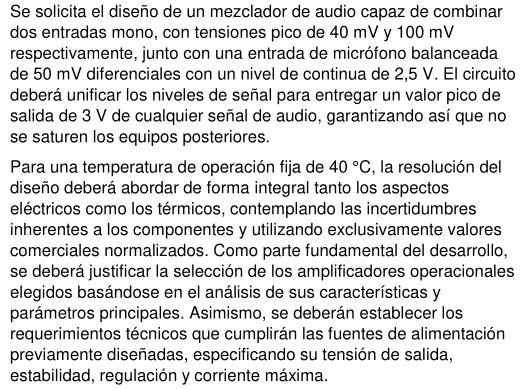

<div style="page-break-after: always;"></div>

## Resumen

En el presente trabajo se diseña, analiza y simula un mezclador de audio que recibe tres señales analógicas. Dos señales mono de 40 mV pico y 100 mV respectivamente y una señal de micrófono balanceado de 50mV pico con una componente de continua de 2.5 V. Este cuenta con dos etapas principales, la primera se encarga de acondicionar y filtrar las señales para entregar en la entrada de la segunda etapa (etapa sumadora) una señal con un nivel de tensión pico de 1V para cada una, garantizando en la salida del sumador una tensión pico de 3 V. El diseño contempla el uso de componentes comerciales y la evaluación de su correspondiente incertidumbre. Además, se realizan simulaciones en LTSpice con modelos ideales y reales para verificar la respuesta en frecuencia y en tiempo dentro de la banda audible (20 Hz - 20 kHz). Finalmente, se realiza un análisis térmico a una temperatura ambiente de 40ºC garantizando una operación segura y estable.

## Abstract

This paper presents the design, analysis and simulation of an audio mixer that inputs three analog signals. Two of those are mono audio of 40 mV peak and 100 mV peak, respectively, and a balanced microphone signal of 50 mV peak with a component of 2.5 V DC. This circuit consists of two main stages: The first one conditions and filters the signals to deliver a signal with a peak voltage of 1 V for each channel to the input of the second stage (the summing stage), ensuring a maximum peak voltage of 3 V at the output of the summing stage. The design incorporates commercial components and evaluates their corresponding uncertainty. Furthermore, LTSpice simulations using ideal and real models are performed to verify the frequency and time response within the audible band (20 Hz - 20 kHz). Finally, a thermal analysis is carried out at an ambient temperature of 40 ºC, guaranteeing safe and stable operation.

<div style="page-break-after: always;"></div>

## 1) Planteo inicial y calculo de las ganancias

Para la implementación se propone una etapa de preamplificación para cada canal de audio que luego se sumarán en un sumador inversor. Para los canales de audio mono se plantea usar un operacional en configuración no inversora y para el canal del micrófono balanceado se propone utilizar un amplificador instrumental discreto implementado con tres operacionales

Para garantizar la protección de los equipos posteriores y cumplir con la consigna de no superar los $ 3 V_{pico} $ a la salida del mezclador, el diseño se fundamenta en el análisis del peor caso. Se asume la posibilidad de que las tres señales de entrada, Canal Mono 1, Canal Mono 2 y micrófono, ingresen en fase y con su máxima amplitud simultáneamente. Por lo tanto, se diseñarán las etapas preamplificadoras para que cada una entregue un máximo de $ 1 V_{pico} $. Posteriormente, un sumador inversor de ganancia unitaria se encargará de realizar la mezcla, asegurando que la suma coherente máxima sea de exactamente $ 3 V_{pico} $, es decir, 1 V + 1 V + 1 V.

### 1.1) Etapas no inversoras:

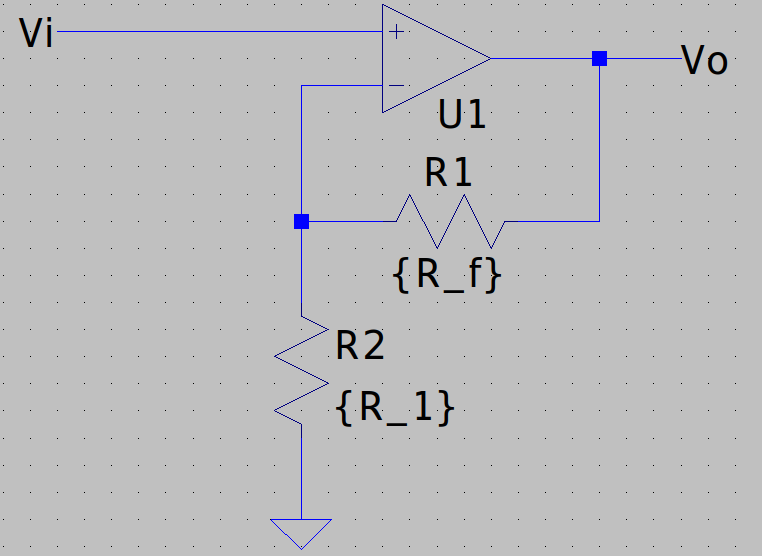

La ganancia de la configuracion no inversora es:

$$ A_v = 1 + \frac{R_f}{R_1} = \frac{V_o}{V_i} $$

Canal mono 1:

$$ V_p = 40mV \quad \implies \quad A_v = \frac{1V}{40mV} = 25 $$

$$ \frac{R_{f1}}{R_{11}} = 25 - 1 = 24 \quad \implies \quad \boxed{\frac{R_{f1}}{R_{11}} = 24} $$

Entonces se adopta:

$$ R_{f1} = 24K\Omega \quad y \quad R_{11} = 1K\Omega \quad \implies \quad \boxed{A_v = 1 + \frac{R_{f1}}{R_{11}} = 1 + \frac{24K\Omega}{1K\Omega} = 25} $$

Canal mono 2:

$$ V_p = 100mV \quad \implies \quad A_v = \frac{1V}{100mV} = 10 $$

$$ \frac{R_{f2}}{R_{12}} = 10 - 1 = 9 \quad \implies \quad \boxed{\frac{R_{f2}}{R_{12}} = 9} $$

Entonces se adopta

$$ R_{f2} = 27K\Omega \quad y \quad R_{12} = 3K\Omega \quad \implies \quad \boxed{A_v = 1 + \frac{R_{f2}}{R_{12}} = 1 + \frac{27K\Omega}{3K\Omega} = 10} $$

### 1.2) Etapa del amplificador de instrumentación

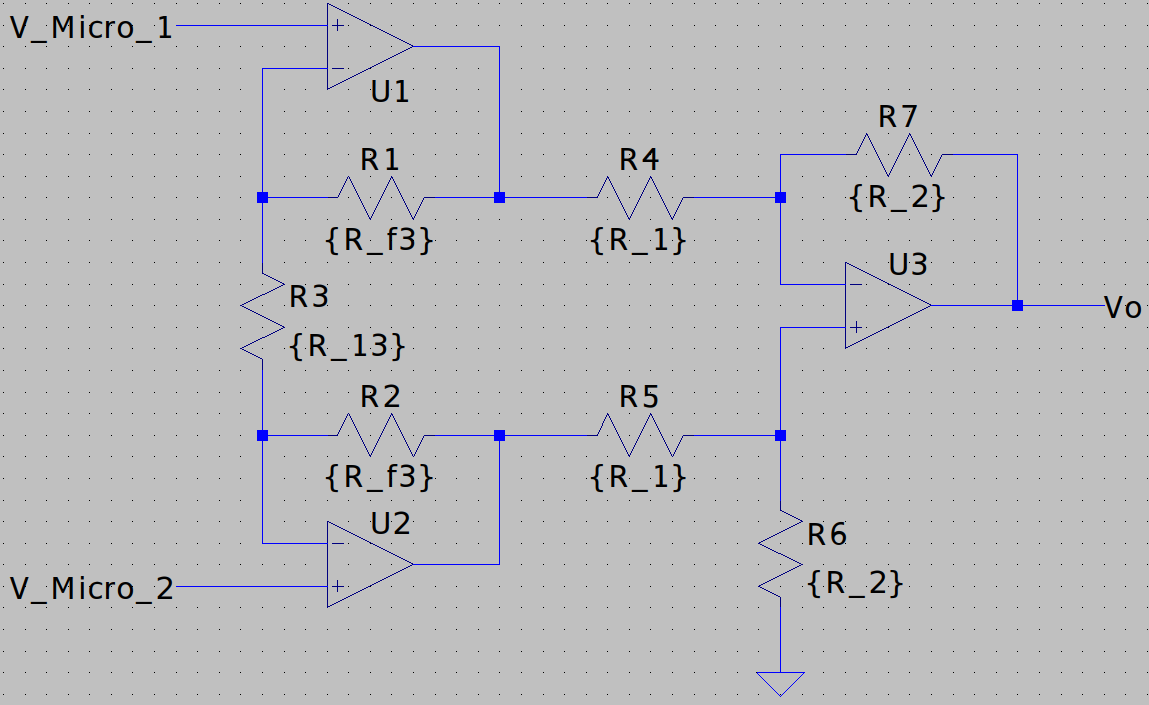

El amplificador instrumental está formado por dos etapas una etapa preamplificadora no inversora y una etapa diferencial, donde se restan las señales.

La etapa no inversora tiene una ganancia de:

$$ A_{v1} = 1 + \frac{2·R_{f3}}{R_{13}} \quad y \quad A_{v1} = \frac{1V}{50mV} = 20 \quad \implies \quad \frac{2·R_{f3}}{R_{13}} = 19 $$

Se adopta:

$$ R_{f3} = 9.53 K\Omega \quad y \quad R_{13} = 1 K\Omega $$

$$ A_{v1} = 1 + \frac{2·9.53 K\Omega}{1 K\Omega} = 1 + \frac{19.06 K\Omega}{1 K\Omega} = 20.06 \quad \implies \quad \boxed{A_{v1} = 20.06} $$

La etapa diferencial tiene una ganancia de

$$ A_{v2} = \frac{R_2}{R_1} $$

Se adopta
$$ R_{1} = 10 K\Omega \quad y \quad R_2 = 10 K\Omega \quad \implies \quad \boxed{A_{v2} = 1} $$

### 1.3) Etapa sumador inversor

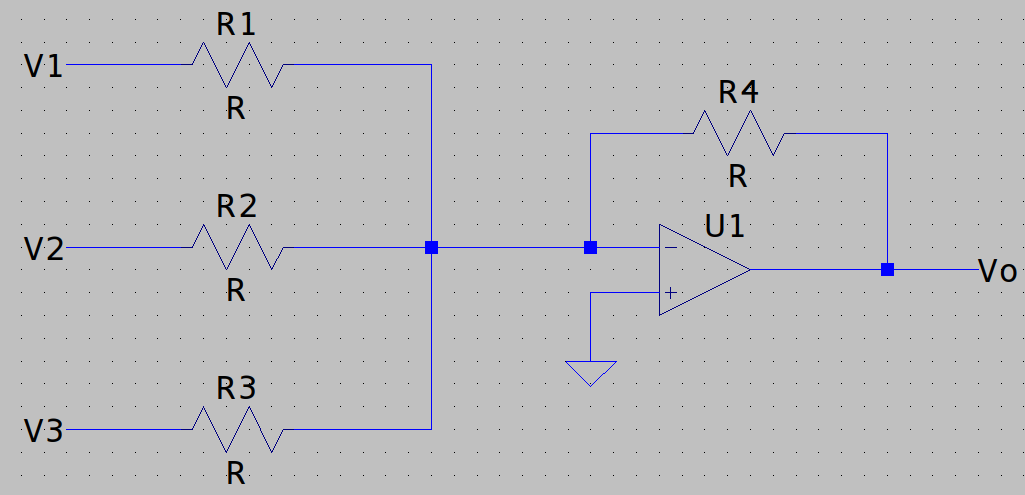

La etapa sumadora tiene una ganacia de

$$ A_{v} = -\left(\frac{R_4}{R_1}V_1 + \frac{R_4}{R_2}V_2 + \frac{R_4}{R_3}V_3 \right) $$

Se adopta: $ R_{1} = R_2 = R_3 = R_4 = 10k\Omega $

Entonces la ganancia de la etapa sumadora es

$$ A_{v} = -(V_1 + V_2 + V_3) $$

## 2) Protecciones

### 2.1) Filtro de Continua

Para eliminar los componentes de continua que puedan estar presentes en la señal de entrada se colocara un capacitor ($C_1$) en serie con cada señal. Eliminando la componente de continua y permitiendo el paso de las componentes de audio.

### 2.2) Resistencia Pull-Down

Como las entradas podrían estar desconectadas, se colocará una señal de resistencia pull-down ($R_G$) a masa para evitar que la entrada quede flotando.

<div style="page-break-after: always;"></div>

## 3) Circuito a implementar

### 3.1)Selección y justificación de componentes activos

Para la implementación física de las etapas de acondicionamiento y mezcla del circuito, se requiere cubrir un total de seis amplificadores operacionales: uno para el preamplificador del Canal Mono 1, uno para el Canal Mono 2, tres destinados al diseño del amplificador de instrumentación de la entrada de micrófono balanceada, y uno para el bloque sumador inversor final.

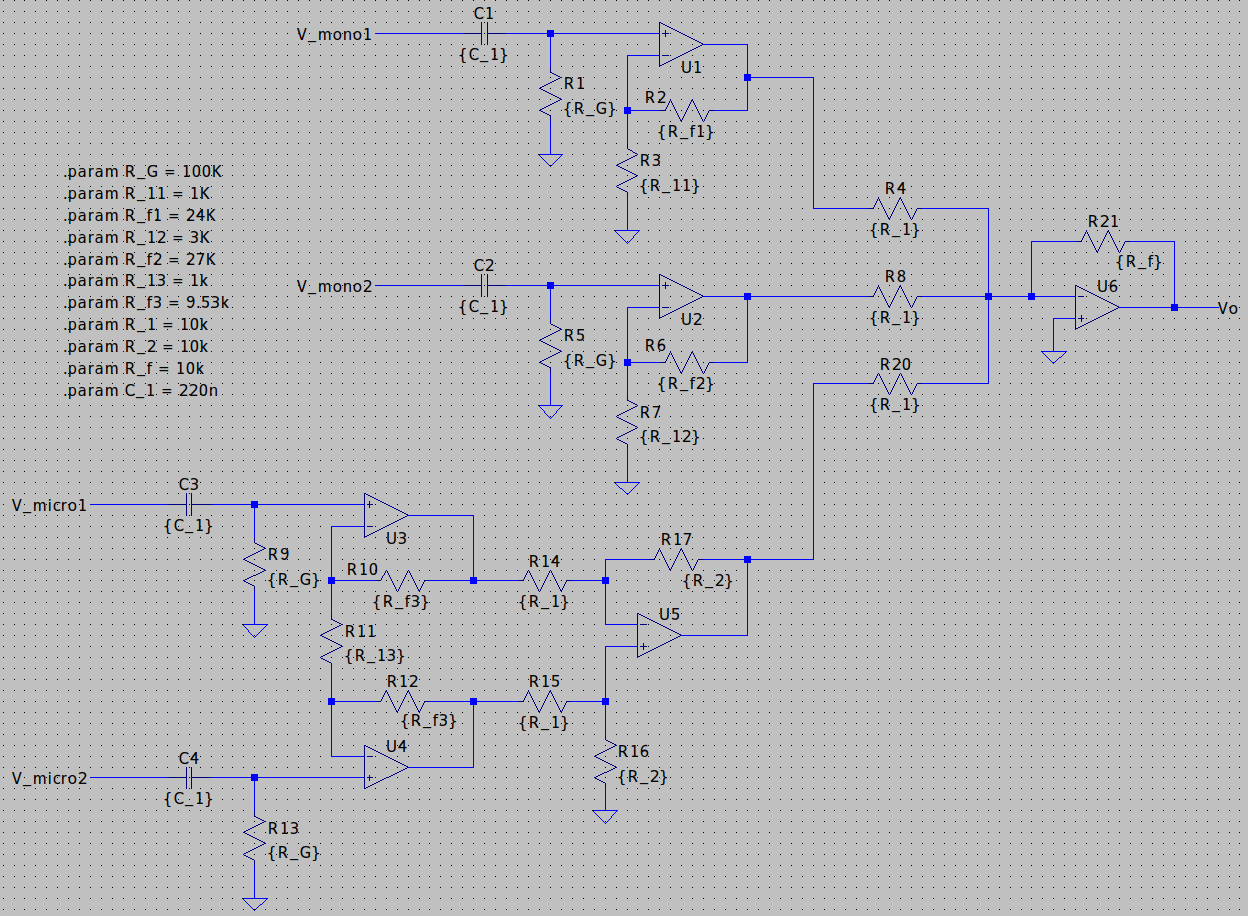

### 3.2) Cálculo de Incertidumbre de los componentes

#### 3.2.1) Análisis de incertidumbre por tolerancias resistivas:

Valores de resistencia adoptados:

$$ R_G = 100K\Omega \quad ; \quad R_{11} = 1 K\Omega \quad ; \quad R_{f1} = 24 K\Omega \quad ; \quad R_{12} = 3 K\Omega $$

$$ R_{f2} = 27 K\Omega \quad ; \quad R_{13} = 1 K\Omega \quad ; \quad R_{f3} = 9.53 K\Omega \quad ; \quad R_{1} = R_{2} = R_{f} = 10 K\Omega $$

Para garantizar la confiabilidad del diseño, se procede a evaluar el error máximo de ganancia introducido por la dispersión de los componentes comerciales. Aunque se utilizan resistores de precisión con tolerancia del 1%, en el peor caso, donde todas las resistencias de realimentación $ R_f $ adoptan su valor máximo de +1% y las resistencias de entrada $ R_i $ o $ R_G $ adoptan su valor mínimo de −1%, la ganancia de cada etapa se apartará de su valor nominal.

El factor de desvío máximo para una relación resistiva simple es $ K_{max} = \frac{1,01}{0,99} ≈ 1,0202 $.

#### 3.2.2) Incertidumbre del canal mono 1

Ganancia nominal: $ A_{v1} = 25 $.

En el peor caso, $ A_{v1(max)} = 1 + (24 · 1,0202) = 25,48 $.

Por lo tanto, la tensión pico entregada al sumador será $ V_{1(max)} = 40 mV · 25,48 = 1,019 V_{pico} $

#### 3.2.3) Incertidumbre del canal mono 2

Ganancia nominal: $ A_{v2} = 10 $. 

En el peor caso, $ A_{v2(max)} = 1 + (9 · 1,0202) = 10,18 $.

Por lo tanto, la tensión pico entregada al sumador será $ V_{2(max)} = 100 mV · 10,18 = 1,018 V_{pico} $

#### 3.2.4) Incertidumbre del canal balanceado

Al estar compuesto por dos etapas, malla de entrada y restador diferencial, el error se propaga multiplicativamente. Para la etapa de entrada, con $ R_{f3} = 9,53 k\Omega \quad y \quad R_{13} = 1 k\Omega$, el peor caso resulta $A_{in(max)} = 1 + \frac{2 · 9,53 k\Omega · 1,01}{1 k\Omega · 0,99} = 20,44 $

Para la etapa restadora, el peor caso se estima como $ A_{diff(max)} = 1 · 1,0202 = 1,0202 $ 

Por lo tanto, la ganancia total máxima será $ A_{v3(max)} = 20,44 · 1,0202 = 20,85 $, y la tensión pico entregada al sumador será $ V_{3(max)} = 50 mV · 20,85 = 1,043 V_{pico} $.

#### 3.2.5) Error acumulado en el sumador inversor final

El sumador final posee una ganancia nominal de −1. En el peor caso, su resistencia de realimentación aumenta un 1% y las tres resistencias de entrada disminuyen un 1%, elevando su ganancia a $|A_{sum(max)}| = 1,0202$.

Asumiendo el escenario extremo de suma coherente, donde las tres señales ingresan en fase y al unísono, la tensión total máxima de salida será $ V_{out(max)} = 1,0202 · (1,019 V + 1,018 V + 1,043 V) = 1,0202 · 3,080 V = 3,14 V_{pico} $

### 3.3) Conclusión

Debido a las tolerancias del 1%, en el caso estadísticamente más desfavorable, la tensión máxima absoluta de salida será de $ 3,14 V_{pico} $. Lo que representa un apartamiento de apenas 4,6% respecto del valor ideal de $ 3 V_{pico} $. Este margen es perfectamente tolerable por el headroom, o margen dinámico, de la fuente de ±15 V, garantizando ausencia de saturación.

<div style="page-break-after: always;"></div>

## 4) Simulacion con amplificadores ideales

### 4.1) Respuesta temporal:

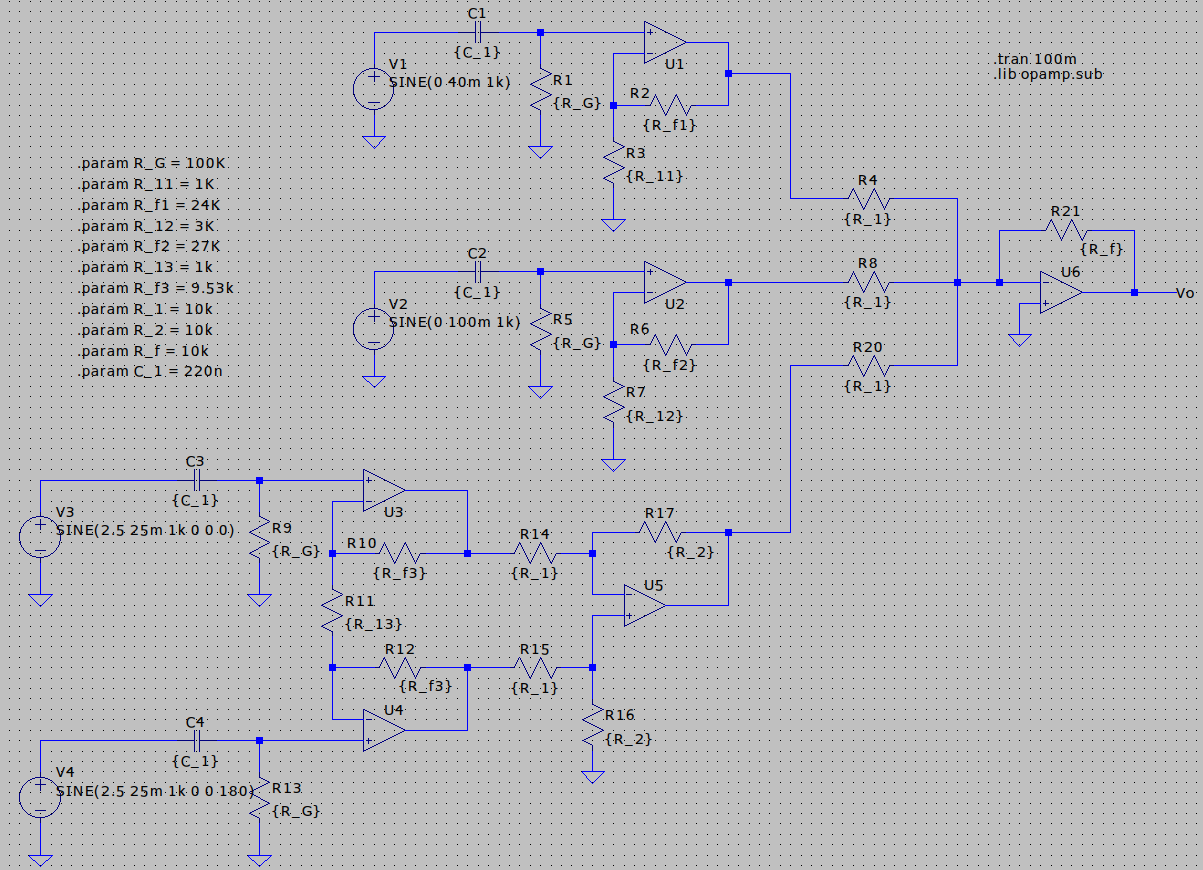

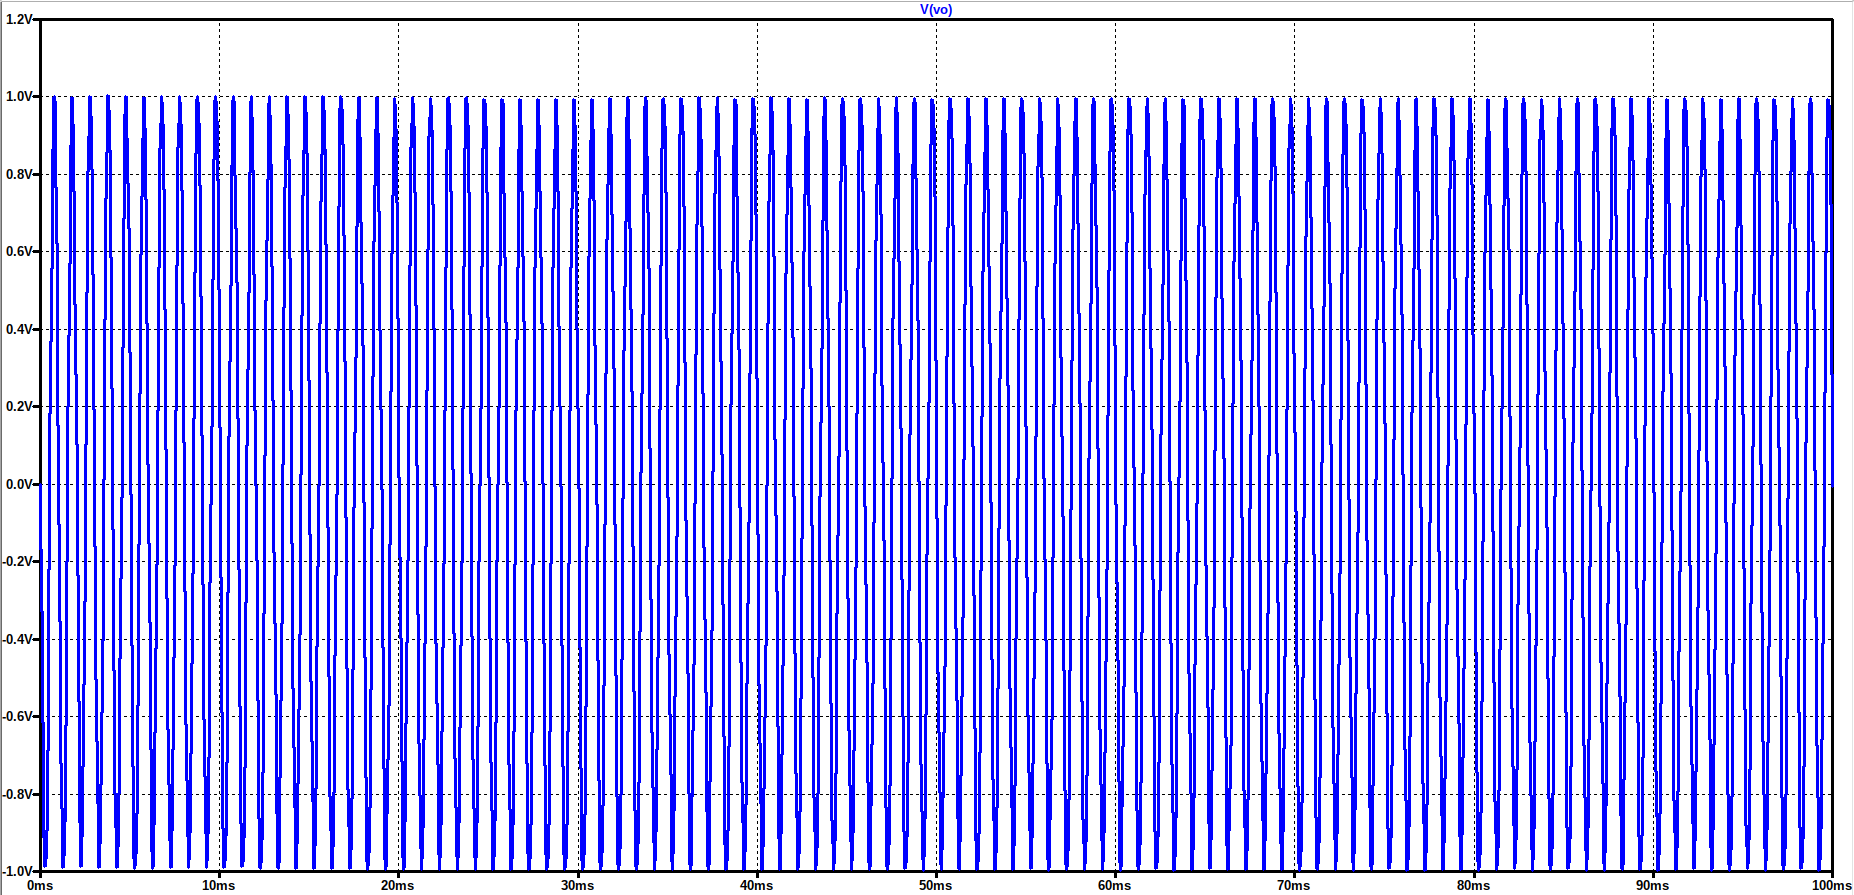

<div style="page-break-after: always;"></div>

### 4.2) Respuesta en frecuencia:

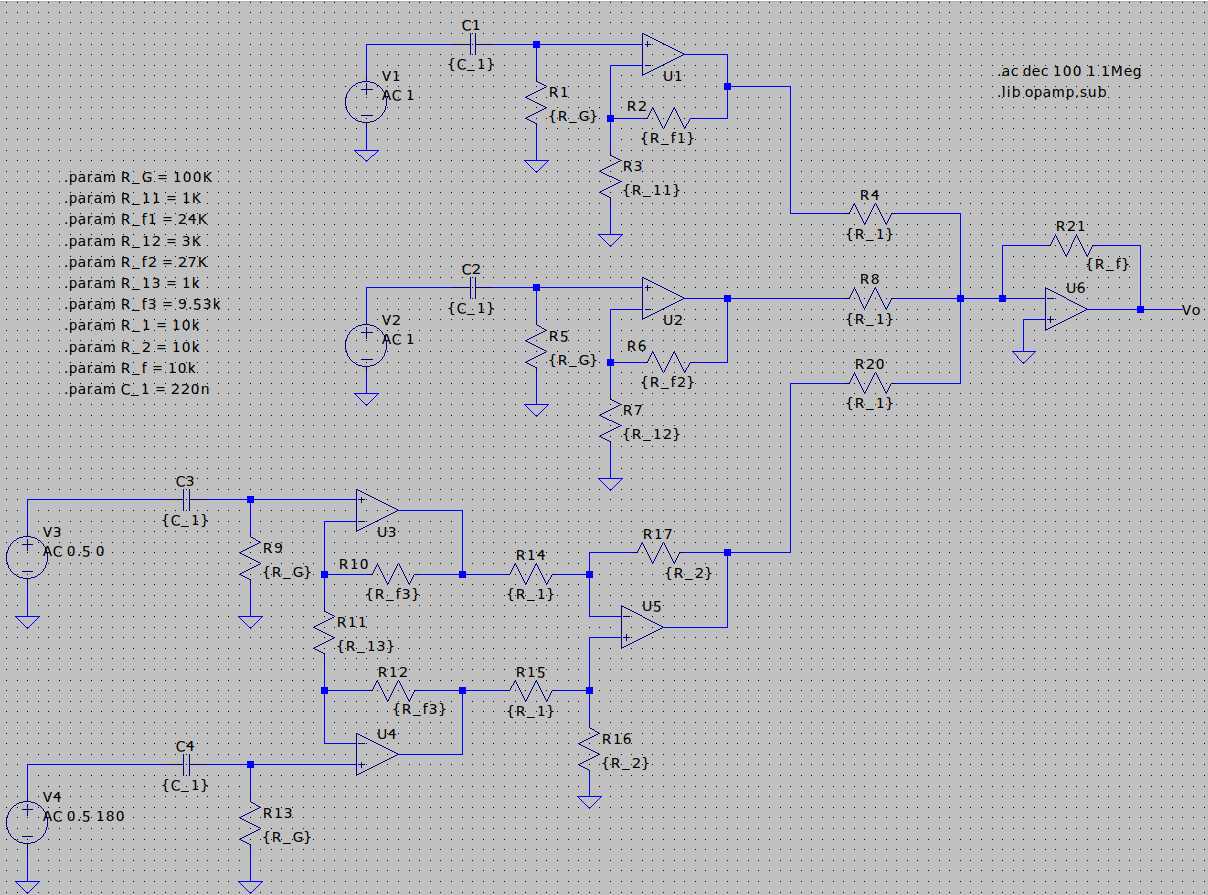

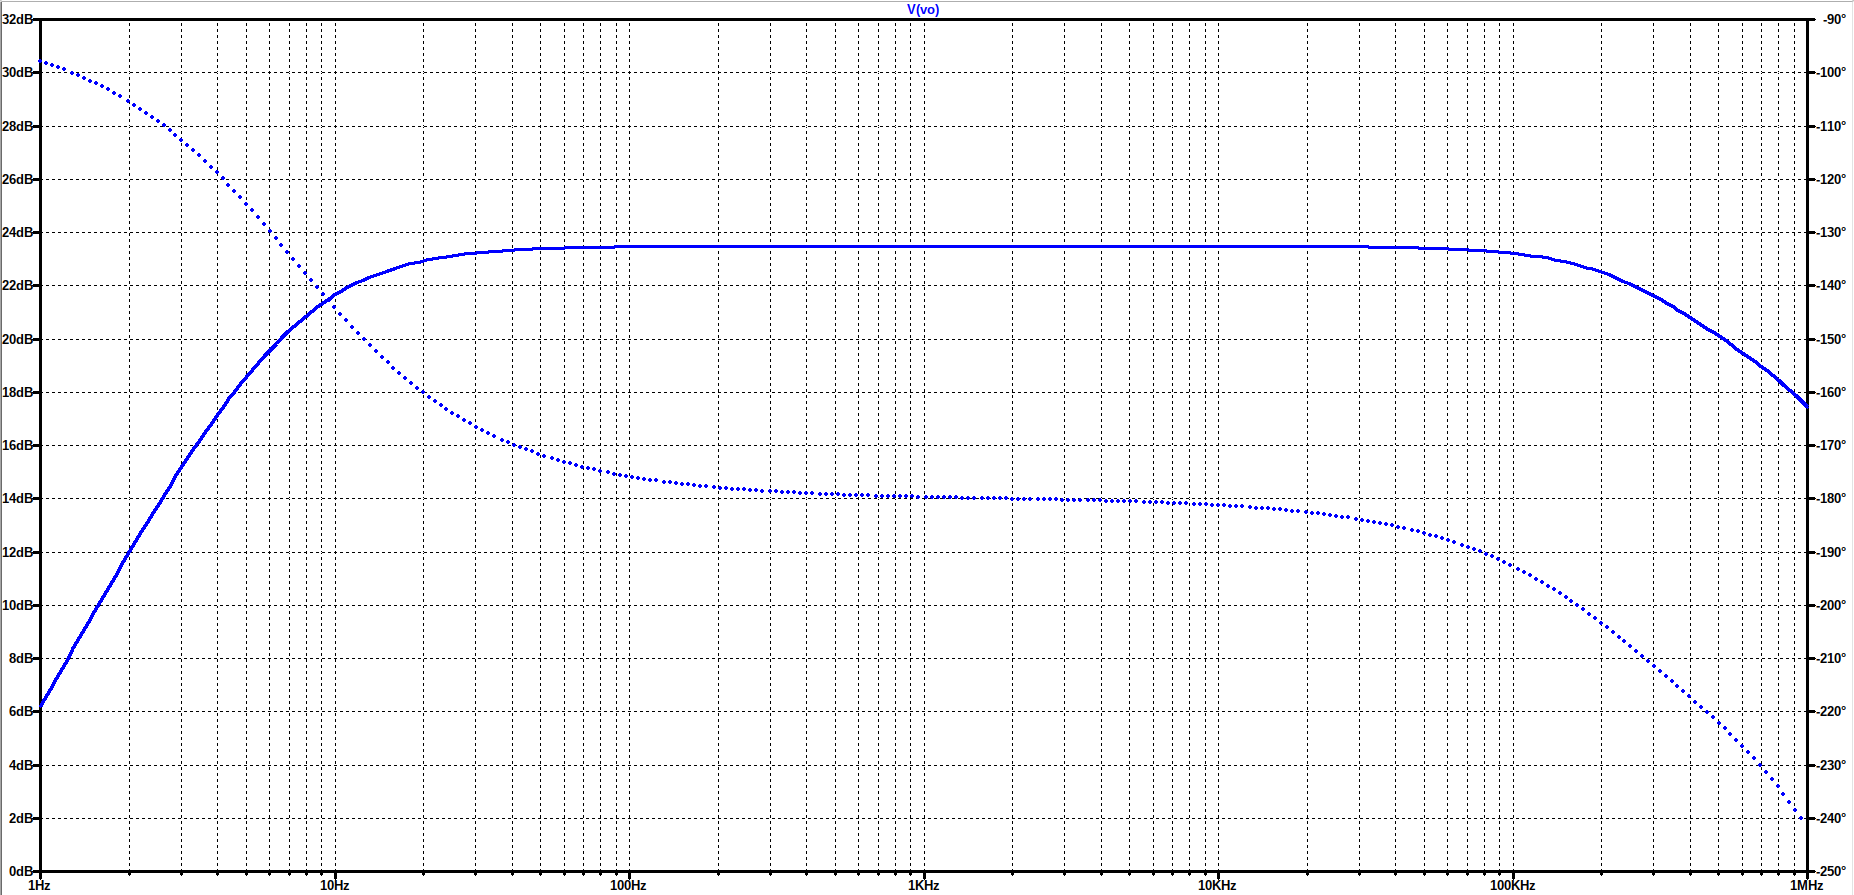

<div style="page-break-after: always;"></div>

## 5) Elección de los amplificadores operacionales

Para la implementación del mezclador de audio se necesitan 6 amplificadores operacionales, dos para la etapa de preamplificación de las señales mono, tres para el amplificador de instrumentación para la etapa de preamplificación de la señal del micrófono balanceado y uno para el sumador. 

Se ha seleccionado la combinación de un circuito integrado cuádruple TL074 (DIP-14) y un integrado doble TL072 (DIP-8) como solución principal. Esta elección responde a tres criterios fundamentales de ingeniería.

### 5.1) Optimización del espacio físico: 

Permite resolver la totalidad de las etapas activas del mezclador utilizando únicamente dos cápsulas integradas en la placa, facilitando un ruteo más compacto y prolijo de la alimentación simétrica en comparación con el uso de tres integrados dobles. El TL074 alberga el amplificador de instrumentación, compuesto por tres operacionales, y el sumador inversor final, mientras que el TL072 se destina exclusivamente a los preamplificadores de los canales mono. 

### 5.2) Acondicionamiento libre de errores de offset por corrientes de polarización:

Al poseer una etapa diferencial de entrada con tecnología de transistores de efecto de campo (JFET), presenta una resistencia de entrada extremadamente elevada de 1012 Ω, equivalente a 1 TΩ, y corrientes de polarización, Ib, excepcionalmente bajas, del orden de 20 pA a 200 pA a temperatura ambiente. Esta característica es crítica para el diseño, ya que en el Canal Mono 1 se calcularon mallas de realimentación con resistencias elevadas. Con corrientes de bias en el rango de los picoamperes, la caída de tensión estática parasitaria, Ib · Rf, es prácticamente nula, lo que evita la necesidad de agregar mallas de compensación externas en los terminales no inversores de los operacionales y simplifica significativamente el circuito.

### 5.3) Respuesta dinámica óptima para audio:

La familia TL07x cuenta con un Slew Rate y un producto ganancia - ancho de banda, que garantizan un seguimiento adecuado de los transitorios de audio rápidos sin introducir distorsión armónica ni limitar la frecuencia de la señal.

### 5.4) Caracteristicas electricas de la familia TL07x

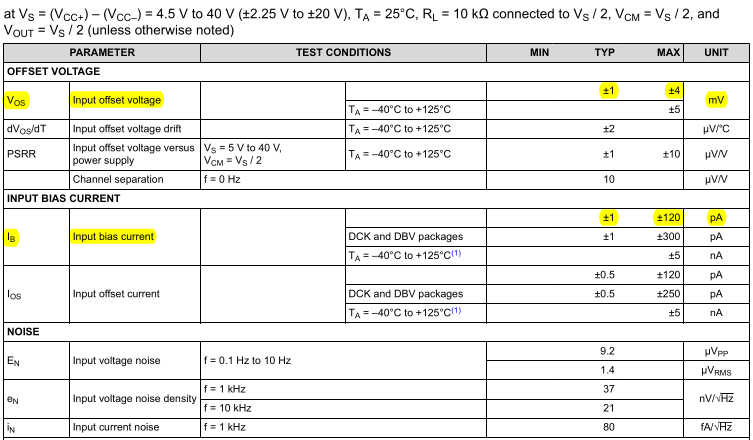

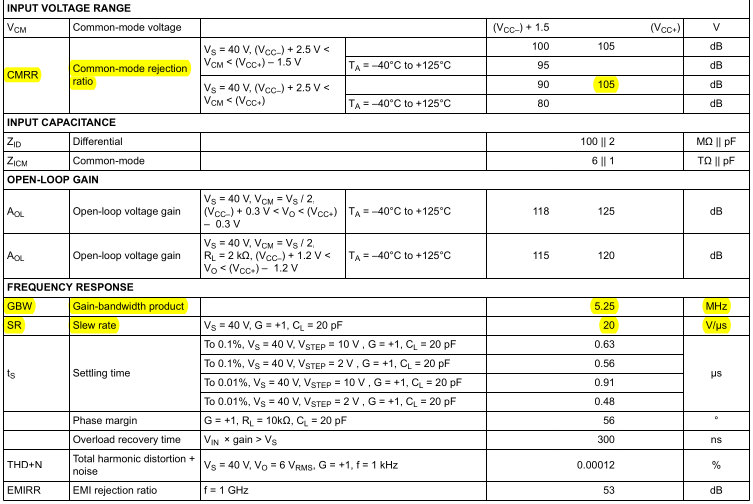

#### 5.4.1) Requerimientos para el TL072:

1) Producto ganancia - ancho de banda (GBW):
    De estas dos etapas la más exigente es la etapa de la señal mono 1, dado que la ganancia necesaria es de 25 veces.
    Esto implica que el $ GBW = 25·20KH_z = 0.5MH_z $
    Como el TL072 tiene un valor de GBW típico de $ 5.25MH_z $, este operacional cumple holgadamente con el requerimiento.

2) Slew Rate (SR):
    El SR minimo requerido es: $ SR \geq 2·\pi·f_{max}·V_{out} = 2·\pi·20KH_z·3V = 0.377 \frac{V}{\mu s} $
    El SR del TL072 es de $ 20\frac{V}{\mu s} $, con lo cual este integrado cumple ampliamente con el requisito.


#### 5.4.2) Requerimientos para el TL074:

1) Producto ganancia - ancho de banda (GBW):
    En la etapa del operacional de instrumentación se busca que tenga una ganancia de 60 veces, por lo tanto el producto de ganancia de ancho de banda necesario es de: $GBW = 20·20KH_z = 0.4 MH_z$.
    Como el TL074 tiene un valor de GBW típico de $5.25MH_z$, este operacional cumple holgadamente con el requerimiento.

2) Slew Rate (SR):
    El SR minimo requerido es: $SR \geq 2·\pi·f_{max}·V_{out} = 2·\pi·20KH_z·3V = 0.377 \frac{V}{\mu s}$
    El SR del TL074 es típicamente de $20\frac{V}{\mu s}$, con lo cual este integrado cumple ampliamente con el requisito.

3) Rechazo al modo común:
   La señal balanceada del micrófono tiene un nivel de continua de 2.5V la cual hay que eliminar en la etapa de preamplificación. El TL074 tiene un rechazo de modo común típicamente de 105 dB.

#### 5.4.3) Calculo de offset

Datos:
$$ V_{IO(MAX)} = 4mV \quad ; \quad I_{B(MAX)} = 120pA $$

Error de Offset del no-inversor del canal 1 (Ganancia de 25 veces)

$$ V_{RO(MAX)1} = V_{IO(MAX)} · 25 + I_{B(MAX)} · R_{f1} + I_{B(MAX)} · R_{G} · 25 $$

$$ V_{RO(MAX)1} = 4mV · 25 + 120pA · 24k\Omega + 120pA · 100k\Omega · 25 = 100 mV $$

Error de Offset del no-inversor del canal 2 (Ganancia de 10 veces)

$$ V_{RO(MAX)1} = V_{IO(MAX)} · 10 + I_{B(MAX)} · R_{f2} + I_{B(MAX)} · R_{G} · 10 $$

$$ V_{RO(MAX)1} = 4mV · 10 + 120pA · 27k\Omega + 120pA · 100k\Omega · 10 = 40 mV $$

Error de Offset del Amplificador de instrumentacion:

El amplificador de instrumentación son dos etapas un no inversor por canal y un restador.

Error de Offset del no-inversor del canal 1 del microfono:

$$ V_{RO(MAX)1} = V_{IO(MAX)} · 20 + I_{B(MAX)} · R_{f3} + I_{B(MAX)} · R_{G} · 20 $$

$$ V_{RO(MAX)1} = 4mV · 20 + 120pA · 9.53k\Omega + 120pA · 100k\Omega · 20 = 80 mV $$

Error de Offset del no-inversor del canal 2 del microfono:

$$ V_{RO(MAX)1} = V_{IO(MAX)} · 20 + I_{B(MAX)} · R_{f3} + I_{B(MAX)} · R_{G} · 20 $$

$$ V_{RO(MAX)1} = 4mV · 20 + 120pA · 9.53k\Omega + 120pA · 100k\Omega · 20 = 80 mV $$

Error de Offset del restador del microfono:

$$ V_{RO(MAX)1} = V_{IO(MAX)} · \left(1+\frac{R_2}{R_1}\right)  = 4 mV · \left(1+\frac{10k\Omega}{10k\Omega}\right) $$

$$ V_{RO(MAX)1} = 4mV · 2 = 8mV $$

Error de Offset del sumador:

$$ V_{RO(MAX)1} = V_{IO(MAX)} · \left(1+\frac{R_f}{R_1 || R_1 ||R_1}\right) + I_{B(MAX)} · (R_1 || R_1 ||R_1) + I_{B(MAX)} · (R_1 || R_1 ||R_1) · \left(1+\frac{R_f}{R_1 || R_1 ||R_1}\right) $$

$$ V_{RO(MAX)1} = V_{IO(MAX)} · \left(1+\frac{10k\Omega}{10k\Omega || 10k\Omega ||10k\Omega}\right) + I_{B(MAX)} · (10k\Omega || 10k\Omega ||10k\Omega) + I_{B(MAX)} · (10k\Omega || 10k\Omega ||10k\Omega) · \left(1+\frac{10k\Omega}{10k\Omega || 10k\Omega ||10k\Omega}\right) $$

$$ V_{RO(MAX)1} = V_{IO(MAX)} · \left(1+\frac{10k\Omega}{\frac{10k\Omega}{3}}\right) + I_{B(MAX)} · \frac{10k\Omega}{3} + I_{B(MAX)} · \frac{10k\Omega}{3} · \left(1+\frac{10k\Omega}{\frac{10k\Omega}{3}}\right) $$

$$ V_{RO(MAX)1} = V_{IO(MAX)} · (1+3) + I_{B(MAX)} · \frac{10k\Omega}{3} + I_{B(MAX)} · \frac{10k\Omega}{3} · (1+3) $$

$$ V_{RO(MAX)1} = 4 mV · 4 + 120 pA · \frac{10k\Omega}{3} + 120 pA · \frac{10k\Omega}{3} · 4 = 16 mV $$

Error de Offset total:

$$ V_{RO(MAX)} = V_{RO(MAX)1} + V_{RO(MAX)2} + V_{RO(MAX)3} + V_{RO(MAX)4} $$

$$ V_{RO(MAX)} = 100 mV + 40 mV + 168 mV + 16 mV \quad \implies \quad \boxed{V_{RO(MAX)} = 324 mV} $$

<div style="page-break-after: always;"></div>

## 6) Simulacion con los modelos reales de los operacionales TL072 y TL074

### 6.1) Respuesta Temporal

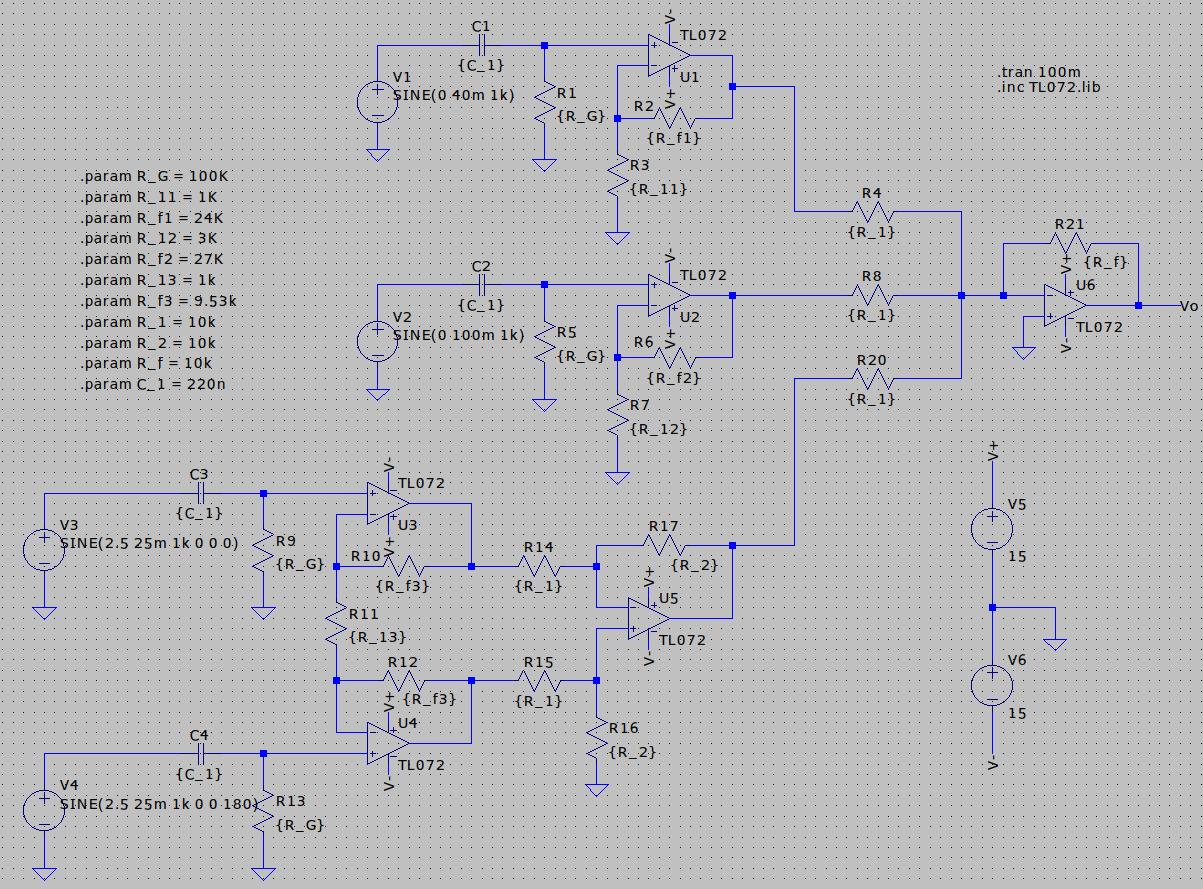

6.1.1) Respuesta con los tres canales con una frecuencia de $1kHz$

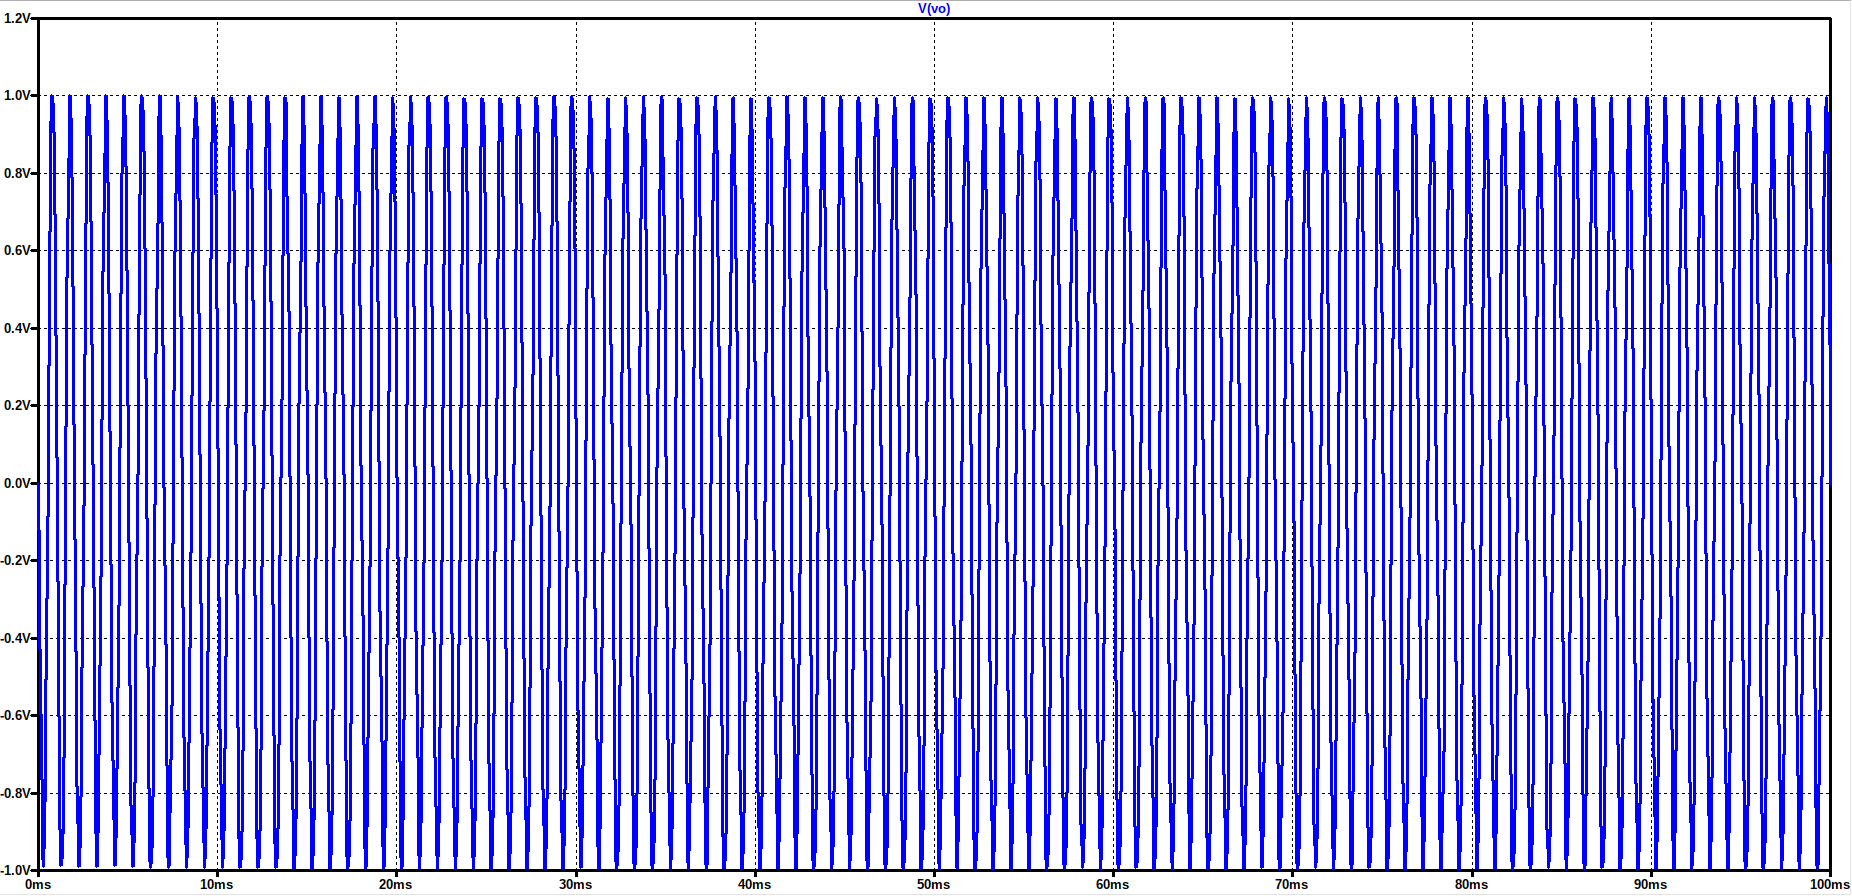

6.1.2) Respuesta con los tres canales con: Canal mono 1 a $f_1 = 100Hz$, Canal mono 2 a $f_2 = 1kHz$ y Canal 3 a $f_3 = 5kHz$ 

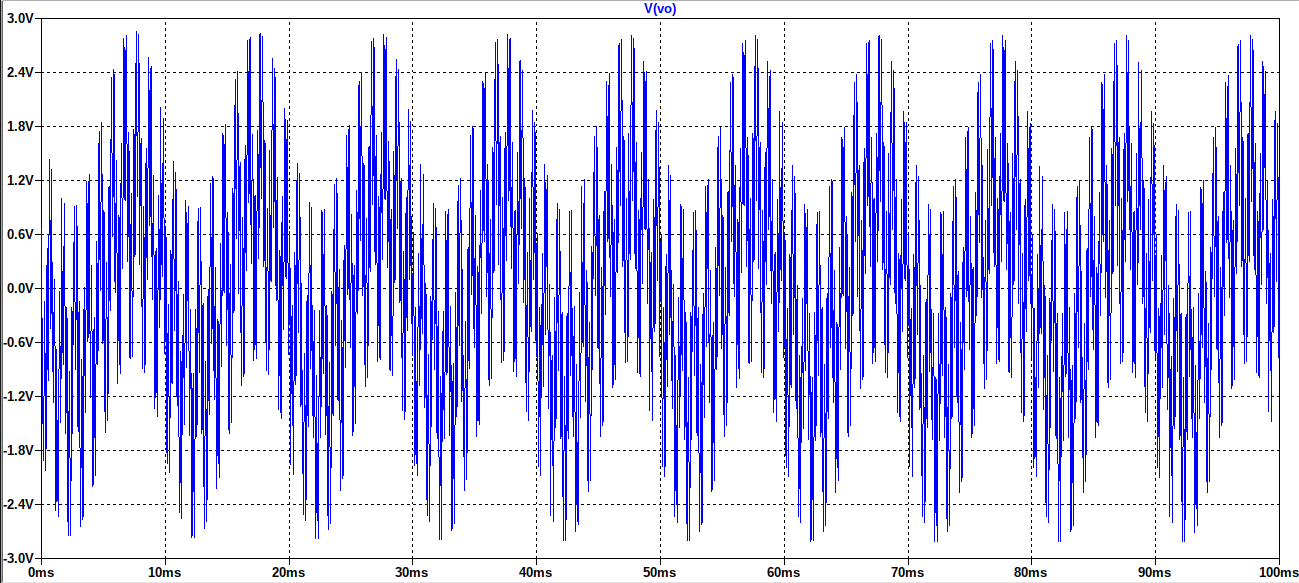

### 6.2) Barrido en Frecuencia

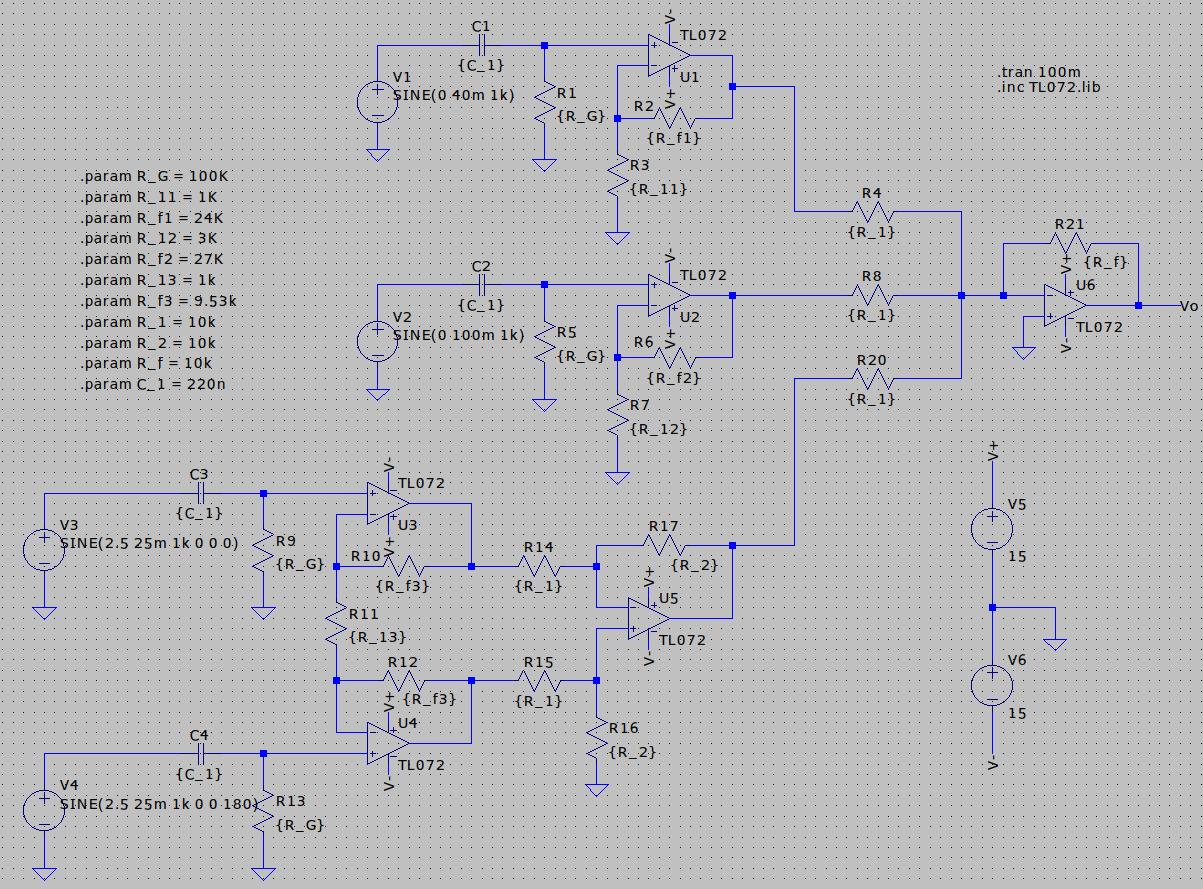

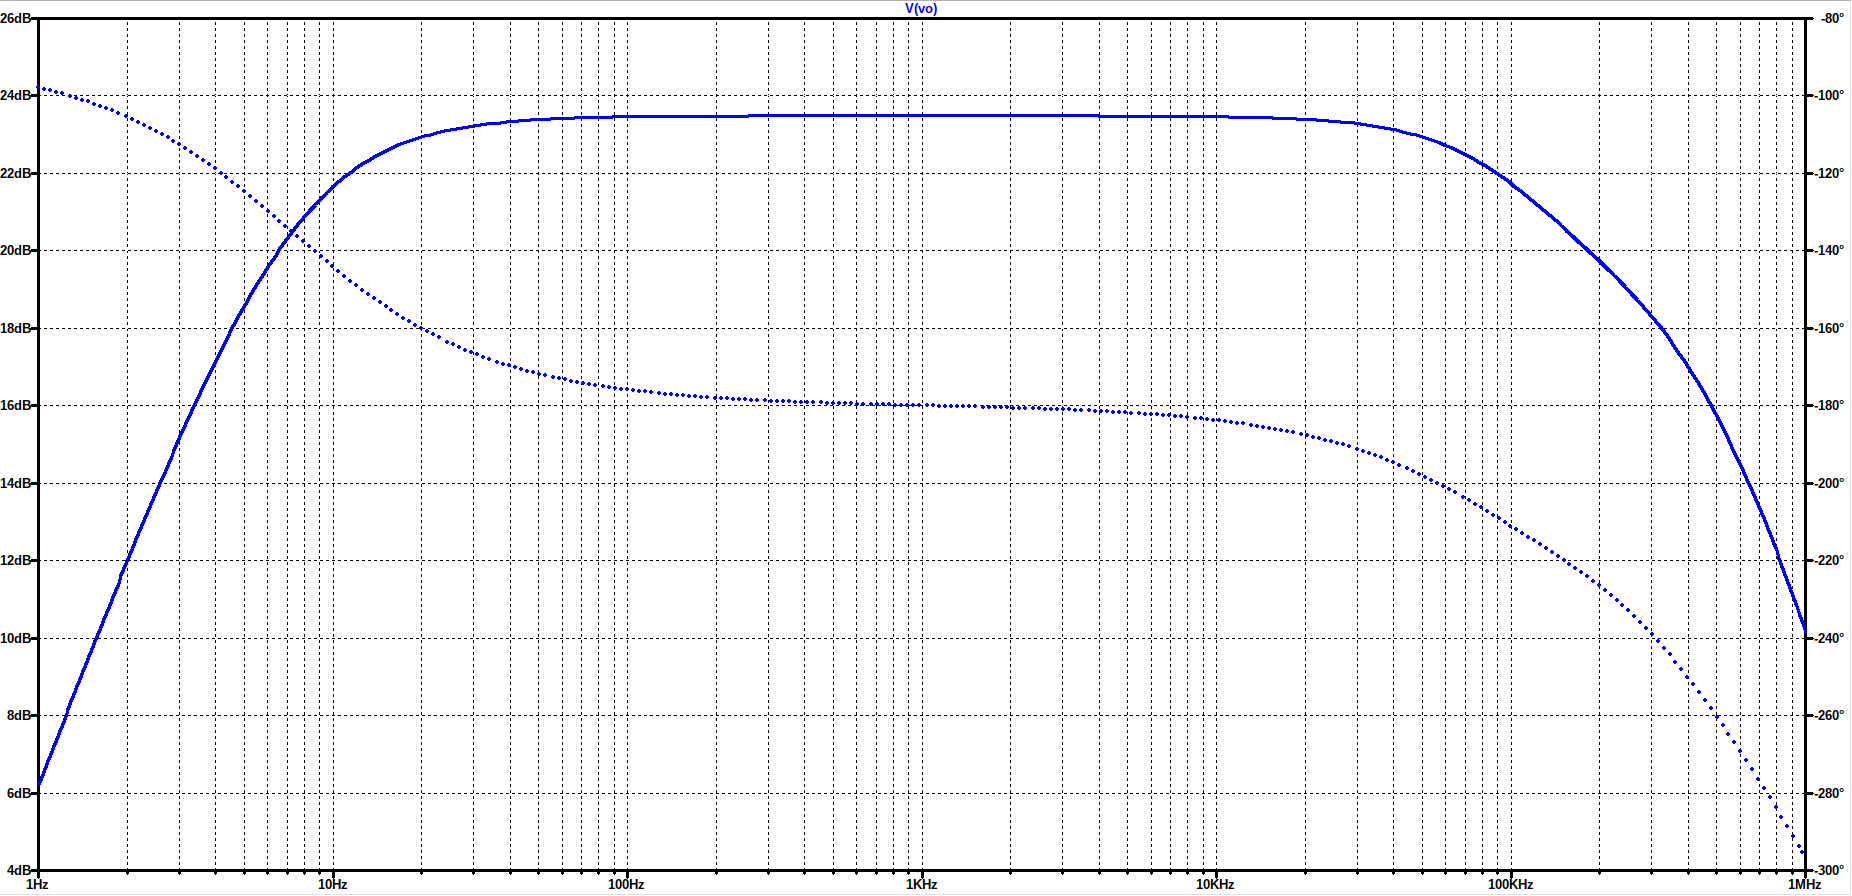

<div style="page-break-after: always;"></div>

## 7) Análisis Térmico

Para hacer el análisis térmico se realiza un circuito eléctrico equivalente, que representa al sistema térmico. En este circuito equivalente las analogías son las siguientes.

    1) Temperatura [ºC] = Tensión [V]
    2) Potencia Disipada [W] = Corriente [A]
    3) Resistencia Térmica [ºC/W] = Resistencia Electrica [Ω]

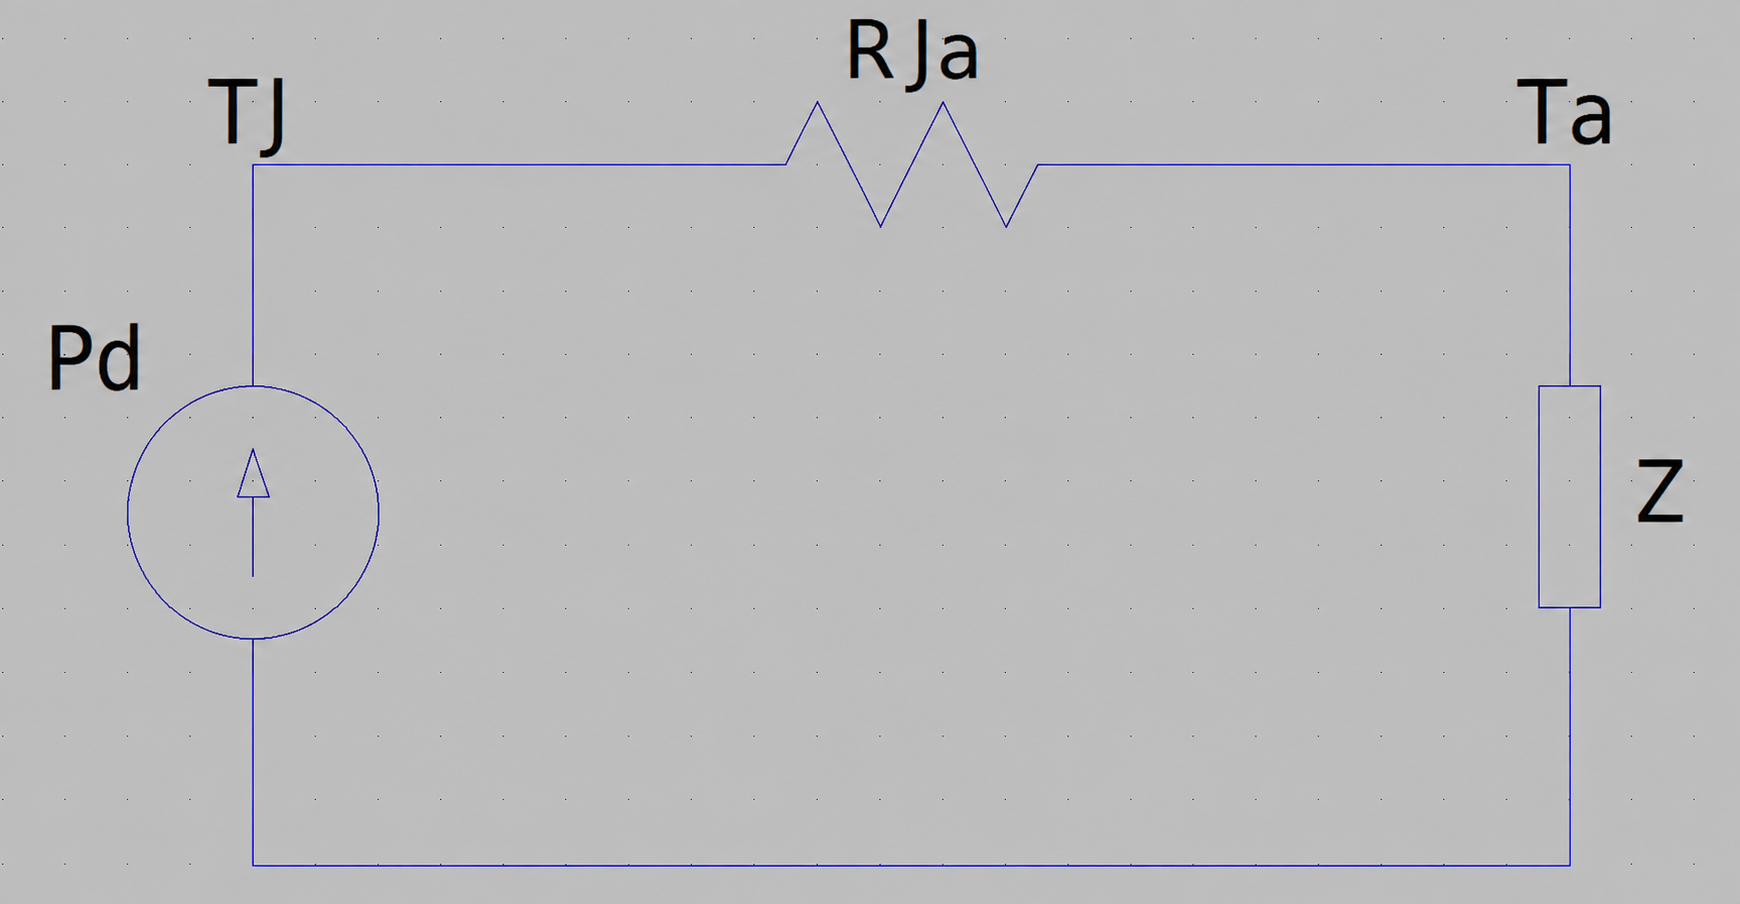

$$T_J = T_a + P_d · R_{Ja} \quad ; \quad P_d = P_Q = \Delta V_S · I_Q \quad y \quad \Delta V_S = V^+ - V^- = 30V$$

Siendo:

1) $T_J$: Temperatura de juntura
2) $T_a$: Temperatura de ambiente ($T_a = 40ºC$)
3) $R_{Ja}$: Resistencia térmica juntura-ambiente
4) $P_d$: Potencia disipada
5) $P_Q$: Potencia en reposo
6) $I_Q$: Corriente de reposo

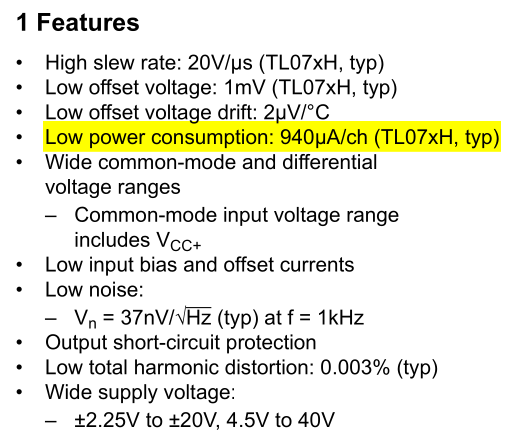

Corriente de reposo por canal: $I_{Q_c} = 940 \mu A$

## TL072

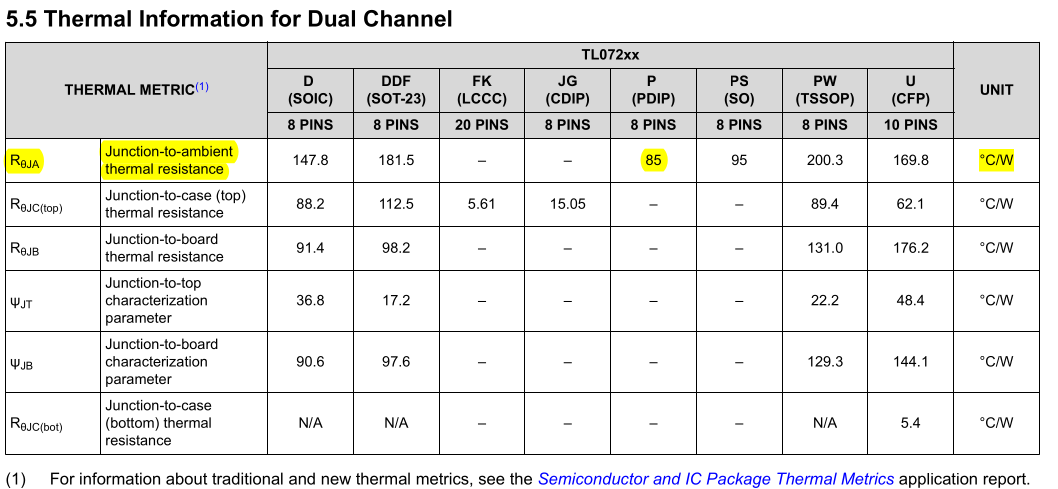

El TL072:
    
1) Tiene 2 opamps $\quad \implies \quad I_Q = 940 \mu A · 2 = 1.88 mA$
   
2) $R_{Ja} = 85 \frac{ºC}{W}$

$$P_d = 30V * 1.88mA = 56.4 mW \quad \implies \quad \boxed{P_d = 56.4 mW} $$

$$T_J = 40ºC + 56.4 mW · 85 \frac{ºC}{W} = 40ºC + 4.794ºC \quad \implies \quad \boxed{T_J = 44.794 ºC}$$

## TL074

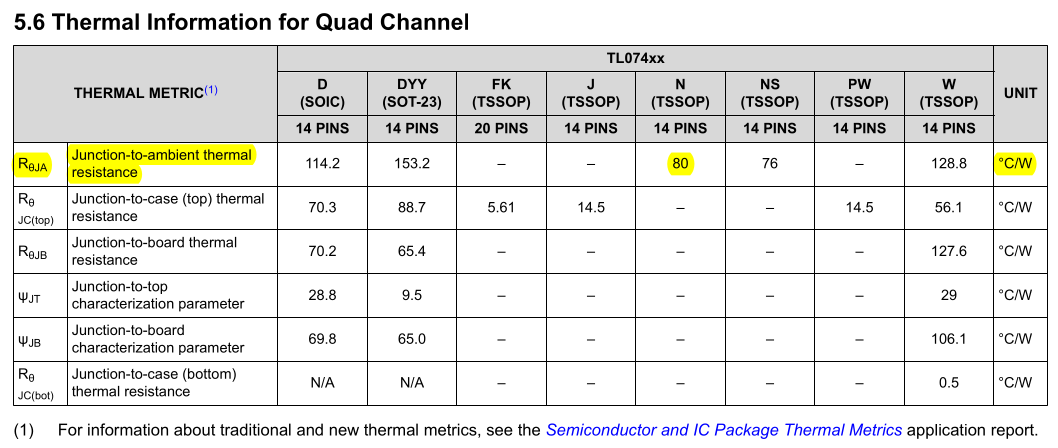

El TL074:
    
1) Tiene 4 opamps $\quad \implies \quad I_Q = 940 \mu A · 4 = 3.76 mA$

2) $R_{Ja} = 80 \frac{ºC}{W}$

$$P_d = 30V · 3.76 mA = 112.8 mW \quad \implies \quad \boxed{P_d = 112.8 mW} $$

$$T_J = 40ºC + 112.8 mW · 80 \frac{ºC}{W} = 40ºC + 9.024ºC \quad \implies \quad \boxed{T_J = 49.024 ºC}$$

<div style="page-break-after: always;"></div>

## 8) Requerimientos técnicos de las fuentes de alimentación

Para energizar las etapas preamplificadoras y el sumador inversor del mezclador de audio, compuestas por un total de seis amplificadores operacionales con entrada JFET, se establece el uso de una fuente de alimentación simétrica regulada linealmente. Para garantizar el correcto funcionamiento eléctrico, la no distorsión de la señal y mantener las interferencias al mínimo, la fuente deberá cumplir con las siguientes especificaciones técnicas.

### 8.1) Tensión de alimentación: ± 5Vdc

De la hoja de datos del TL072 la tensión de salida pico máxima $V_{om}$ (a $V_{cc} = ±5v$) es $±3.5v @ R_L = 2k$ y el rango de excursión máxima de señal pedido es de $3 V_{pico}$. Este valor proporciona un margen dinámico, o headroom, óptimo frente al límite de $3 V_{pico}$ de la señal de salida máxima estipulada, evitando el riesgo de saturación.

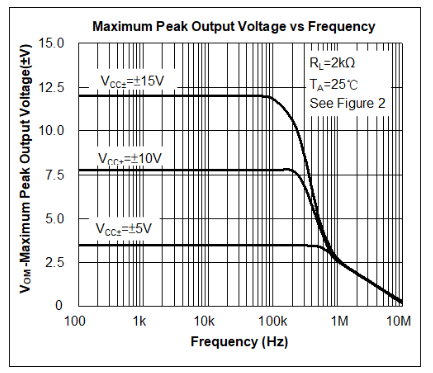

### 8.2) Corriente máxima:

De la hoja de datos del TL072 la corriente de salida $I_{O_{Pico(max)}} = 1.75mA \quad y \quad V_{cc} = ±5v \quad ; \quad R_L = 2k)$. La $I_{cc}$ es de $2.5mA$ máximo. Esto da $4.25mA$ más el $15\%$ de margen, da $5mA$ por Operacional. Son $6\,\, OpAmps\,\, ·\,\, 5mA = 30mA$. 

Del Datasheet del TL072 la $I_{os}$ (short-circuit  Output  Current) $= 26mA \quad \implies \quad 6\,\, OpAmps \,\, · \,\,26mA = 156mA$. 

Se elige una $I_o$ de fuente de 500 mA por cada rama, positiva y negativa. Dado que el consumo estático de los seis operacionales ronda los 5mA totales, más la exigencia de corriente dinámica de las mallas, menor a 5mA, y la corriente de cortocircuito, la especificación de 500mA provee un factor de seguridad holgado.

#### 8.2.1) Del Datasheet del LM7805:

$$ V_o,\quad T_J = 25ºC,\quad 5mA \leq I_o \leq 1A,\quad 4.8v \leq V_o \leq 5.2v $$

$$ V_o = 4.8v(96\% de 5v) \quad \implies  V_{om} = 3.5v·0.96 = 3.36v > 3_{vp} $$
   
#### 8.2.2)Del Datasheet del LM7905:

$$ V_o,\quad T_J = 25ºC,\quad 5mA \leq I_o \leq 1A,\quad -4.8v \leq V_o \leq 5.2v $$

$$ V_o = -4.8v(96\% de 5v) \implies V_{om} = -3.5v·0.96 = -3.36v < -3_{vp} $$


#### Datos finales:

- $V_i = 9V$ (Salida de puente rectificador y capacitores)

- $V_o = ±5V_{DC}$

- $I_o = 500mA$

### 8.3) Otras características del LM7805

- Drop-Out Voltage: $V_{do} = 2V \quad @ \quad I_o = 1A, \quad T_J = 25ºC \quad$

- Output Noise Voltage: $V_{N} = 40 \mu V \quad @ \quad T_A = 25ºC, \quad 10 H_Z \leq f \leq 100kH_Z \quad$

- Ripple Rejection: $68dB \quad @ \quad f = 120H_Z, \quad I_o \leq 500mA, \quad 0ºC < T_J < +125ºC$

- Short-Circuit Current: $2.1A \quad @ \quad V_o = 5V$

### 8.4) Calculo de potencia

- Tomando una $V_i$ de 9V y variación del 20%: $P_d = |V_o-V_{i(max)}|·I_o = |5V - 10.8V|·500mA = 3W$

### 8.5) Regulación de línea, carga y estabilidad

#### 8.5.1) Regulacion de línea (ΔVin)

Del Datasheet del LM7805: 

$$ \Delta V_o = 50mV, \quad \Delta V_{in}:\,\, 8V \leq V_{in} \leq 20V $$

$$ T_J < 125ºC \quad @ \quad I_o = 500mA \quad ; \quad V_{cc} = 5V $$

- RegLinea: $\frac{\Delta V_o}{\Delta V_{in}} = \frac{50mV}{12V} = 4.2 mV/V$

- Tomando $V_{in} = 9V$ y 20% de variación: $7.2V \leq V_{in} \leq 10.8V \quad \implies \quad V_o = 5V ± 7.5mV $

#### 8.5.2) Regulacion de carga (ΔIo)

Del Datasheet LM7805: $\Delta V_o = 50mV, \quad I_o:\,\, 5mA \leq I_o \leq 1A, \quad V_{cc} = 5V$

- RegLoad: $\frac{V_{NL} - V_{FL}}{\Delta I_L} = \frac{\Delta V_o}{I_{o(max)} - I_{o(min)}} = \frac{50mV}{1A - 5mA} = 50m\frac{V}{A}$

- Tomando $I_o = 500mA$ y 20% de variación:

$$ 400mA \leq I_o \leq 600mA \quad \implies \quad \frac{50mV}{1A}·0.6A = 30mV $$

$$ V_o = 5V-30mV = 4.97V $$

- Tomando la peor condición: $V_{in}=8V \quad y \quad I_o = 600mA$

Entonces:
$$ V_o = 4.8V(96\% de 5V) - 7.5mV -30mV = 4.7625V $$

$$ V_{om} (del\,\, OpAmp) = 4.7625V - 1.5V(No\,\, es\,\, Rail\,\, to\,\, Rail) = 3.6265V > 3V_P $$

Variación de la tensión de salida: $\quad \frac{7.5mV + 30mV}{5V}*100\% = 0.75\% < 1\% $

Para prevenir el acoplamiento de zumbidos de baja frecuencia, 50/100 Hz, en la etapa diferencial de micrófono, se exige una regulación de carga y de línea estricta, con una variación menor al 1%, y un nivel de rizado, o ripple, fuertemente atenuado, no superior a $10 mV_{pico}$.

### 8.6) Ripple y Ruido

El Ripple presente en el nodo de salida del regulador es la combinación de fuentes de ruido independientes:

Ripple Salida = Ripple Entrada atenuado + Ruido térmico interno

Datos:

- Frecuencia de Red: Frecuencia de la línea comercial en Argentina: 50 Hz

- Frecuencia de ripple: Onda duplicada tras pasar por un rectificador de onda completa: 100 Hz

- Rechazo al ripple (PSRR): Capacidad del chip para atenuar el rizado de entrada a 100 Hz: 62 dB

- Voltaje de Ruido (Vn): Ruido térmico inherente al circuito interno de silicio: 40 μV RMS (Banda 10 Hz - 100 kHz)

- Corriente consumida por el circuito Io = 500 mA

- Capacitor de filtro principal en la entrada Cin: 2200 μF (0.0022 F)

Cálculo del ripple en el nodo de entrada: 

- $V_{r(in)} = \frac{I_o}{ripple\,\, ·\,\, Cin} = \frac{0.5A}{100H_Z · 0.0022F} = 2.27V_{pp}$

Cálculo de la atenuación del regulador. Se transforma el PSRR de escala logarítmica (dB) a una escala lineal de atenuación:

- Factor de atenuación lineal = $10^{\frac{PSRR_dB}{20}} = 10^{\frac{62}{20}} = 1258$

Aplicando este factor al rizado bruto calculado en la entrada:

- Ripple Entrada Atenuado = $\frac{2.27V_{pp}}{1258} = 1.8mV_{pp}$

Cálculo del Ruido Térmico de salida. Se aplica el factor de conversión estocástica (6σ) al parámetro RMS provisto por el fabricante para obtener su comportamiento pico a pico:

- Ruido Térmico Interno = $40 \mu V_{RMS} · 6 = 240 \mu V_{pp} = 0.24 mV_{pp}$




Suma total de Ripple y Ruido. Se establece el peor escenario de ruido sobre la carga:

- Ripple Salida Total = $1.8mV_{pp} + 0.24mV_{pp} = 2.04mV_{pp}$

#### Circuito Propuesto

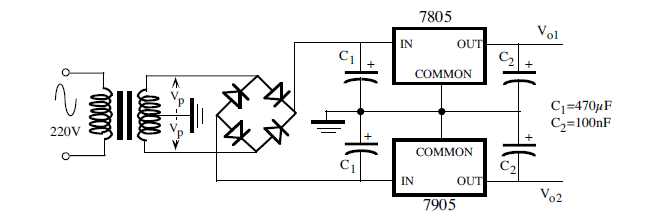

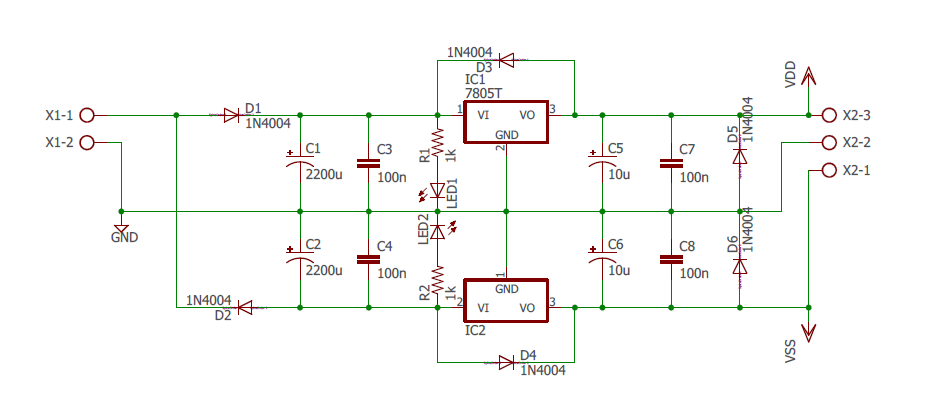

#### Fuente de Alimentación:

1) Tensión de salida nominal: ±5v DC (Simetrica)
2) Corriente de salida por rama: $I_o = 500mA$
3) Tolerancia: ±1%
4) Regulación de línea: 50mV en todo el rango de 4.2mV/V
5) Regulación de carga: 50mV/A para variaciones de carga de 0 a carga máxima
6) Ripple y Ruido: < 0.1%, 2mVpp @ Vcc = 5V

<div style="page-break-after: always;"></div>

## 9) Referencias

9.1) [Datasheet Texas Instruments TL07x](./archivos/PDFs/tl072-tl074.pdf)

9.2) [Datasheet National Semiconductors LM78XX](./archivos/PDFs/LM78XX.PDF)

9.3) Reguladores Serie de tensión. Apunte de Cátedra Electrónica Aplicada II – UTN -FRBA